# Compare between GPT 5.2, GPT 5.4, GPT 5.5

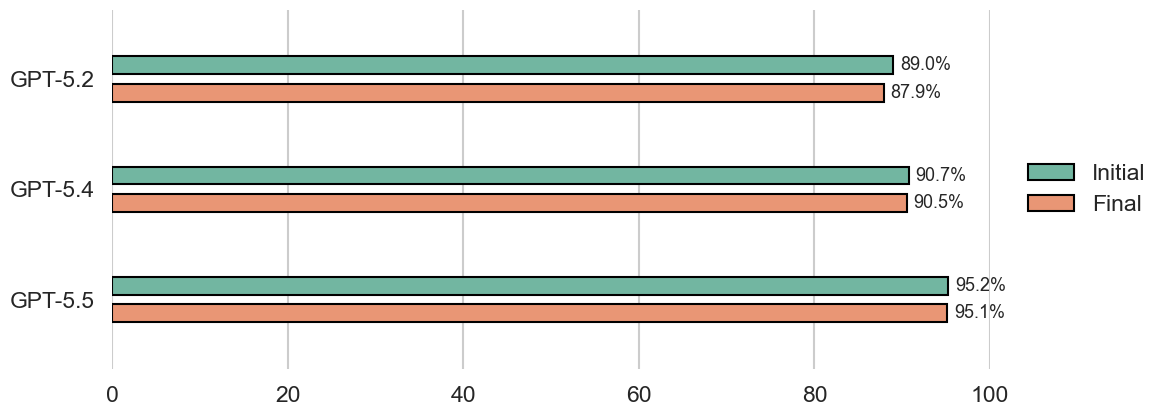

,model,stage,accuracy,n
0,GPT-5.2,Initial,89.002357,1273
1,GPT-5.2,Final,87.902592,1273
2,GPT-5.4,Initial,90.730558,1273
3,GPT-5.4,Final,90.494894,1273
4,GPT-5.5,Initial,95.208170,1273
5,GPT-5.5,Final,95.129615,1273


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

df_question = pd.read_csv("test.csv")

df_52 = pd.read_csv("./run2 gpt all/run2_gpt5_2.csv")
df_54 = pd.read_csv("./run2 gpt all/run2_gpt5_4.csv")
df_55 = pd.read_csv("./run2 gpt all/run2_gpt5_5.csv")

df_question = df_question.dropna(axis=1, how="all")

df_52 = df_52.merge(df_question, on="id", how="left")
df_54 = df_54.merge(df_question, on="id", how="left")
df_55 = df_55.merge(df_question, on="id", how="left")

dfs = {
  "GPT-5.2": df_52.copy(),
  "GPT-5.4": df_54.copy(),
  "GPT-5.5": df_55.copy()
}

accuracy_rows = []

for model_name, df in dfs.items():
  df = df.dropna(
    subset=[
      "run2_initial_answer",
      "run2_answer",
      "answer_idx"
    ]
  ).copy()

  df["run2_initial_answer"] = df["run2_initial_answer"].astype(str).str.strip()
  df["run2_answer"] = df["run2_answer"].astype(str).str.strip()
  df["answer_idx"] = df["answer_idx"].astype(str).str.strip()

  initial_accuracy = (df["run2_initial_answer"] == df["answer_idx"]).mean() * 100
  final_accuracy = (df["run2_answer"] == df["answer_idx"]).mean() * 100

  accuracy_rows.append({
    "model": model_name,
    "stage": "Initial",
    "accuracy": initial_accuracy,
    "n": len(df)
  })

  accuracy_rows.append({
    "model": model_name,
    "stage": "Final",
    "accuracy": final_accuracy,
    "n": len(df)
  })

acc_df = pd.DataFrame(accuracy_rows)

plt.figure(figsize=(12, 4.5))

ax = sns.barplot(
  data=acc_df,
  y="model",
  x="accuracy",
  hue="stage",
  orient="h",
  palette="Set2",
  edgecolor="black",
  width=0.5
)

for patch in ax.patches:
  current_height = patch.get_height()
  new_height = current_height * 0.65
  diff = current_height - new_height
  patch.set_height(new_height)
  patch.set_y(patch.get_y() + diff / 2)

for container in ax.containers:
  ax.bar_label(
    container,
    fmt="%.1f%%",
    padding=5,
    fontsize=13
  )

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(0, 100)

ax.legend(
  title="",
  loc="center left",
  bbox_to_anchor=(1.02, 0.5),
  frameon=False
)

ax.margins(y=0.15)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

acc_df

# Calibration

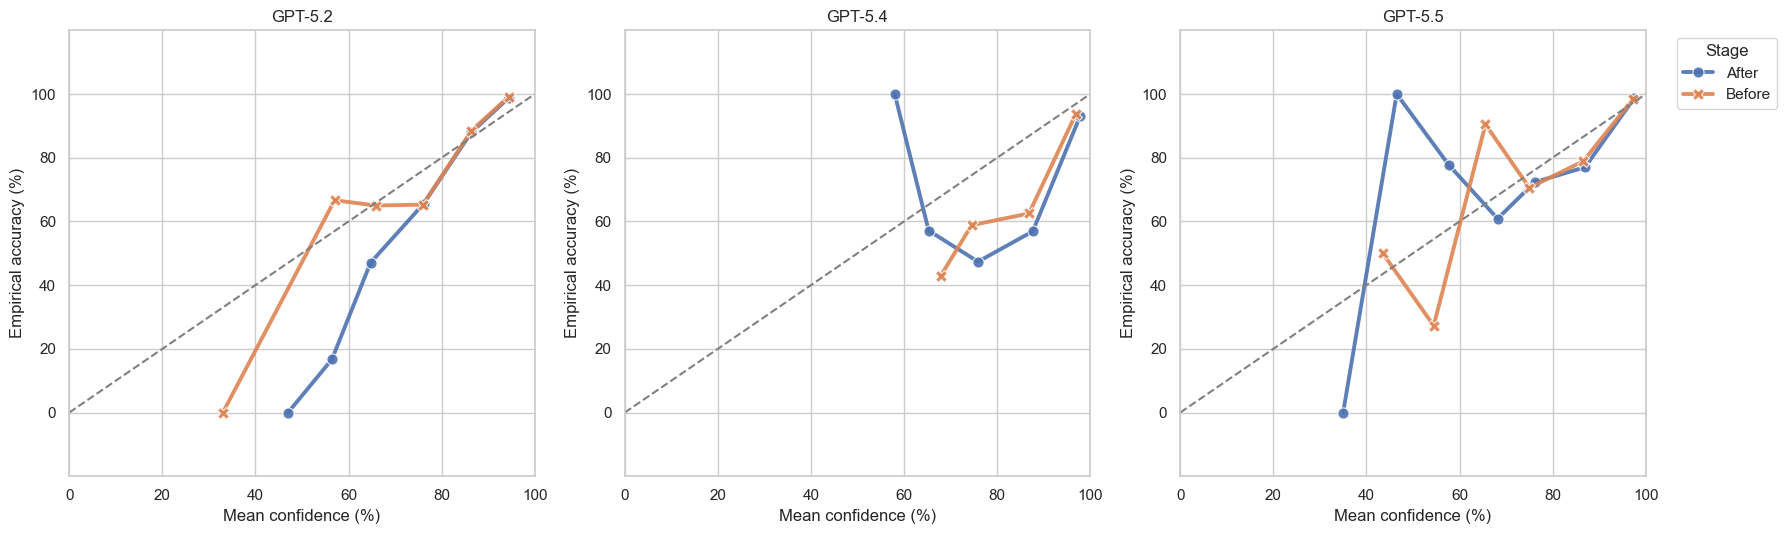

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
  "GPT-5.2": df_52,
  "GPT-5.4": df_54,
  "GPT-5.5": df_55
}

n_bins = 10
bins = np.linspace(0, 100, n_bins + 1)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 5.5))

for i, (model_name, df_model) in enumerate(models.items(), 1):
  df = df_model.copy()

  df = df.dropna(
    subset=[
      "run2_initial_confidence",
      "run2_confidence",
      "run2_initial_answer",
      "run2_answer",
      "answer_idx"
    ]
  ).copy()

  df["run2_initial_confidence"] = pd.to_numeric(df["run2_initial_confidence"], errors="coerce")
  df["run2_confidence"] = pd.to_numeric(df["run2_confidence"], errors="coerce")

  df = df.dropna(subset=["run2_initial_confidence", "run2_confidence"]).copy()

  df["run2_initial_answer"] = df["run2_initial_answer"].astype(str).str.strip()
  df["run2_answer"] = df["run2_answer"].astype(str).str.strip()
  df["answer_idx"] = df["answer_idx"].astype(str).str.strip()

  df["initial_correct"] = df["run2_initial_answer"] == df["answer_idx"]
  df["final_correct"] = df["run2_answer"] == df["answer_idx"]

  df_initial = df[["run2_initial_confidence", "initial_correct"]].copy()
  df_initial = df_initial.rename(
    columns={
      "run2_initial_confidence": "confidence",
      "initial_correct": "correct"
    }
  )
  df_initial["stage"] = "Before"

  df_final = df[["run2_confidence", "final_correct"]].copy()
  df_final = df_final.rename(
    columns={
      "run2_confidence": "confidence",
      "final_correct": "correct"
    }
  )
  df_final["stage"] = "After"

  df_long = pd.concat([df_initial, df_final], ignore_index=True)

  df_long["confidence_bin"] = pd.cut(
    df_long["confidence"],
    bins=bins,
    include_lowest=True,
    right=True
  )

  calib = (
    df_long
    .groupby(["stage", "confidence_bin"], observed=False)
    .agg(
      mean_confidence=("confidence", "mean"),
      empirical_accuracy=("correct", "mean"),
      n=("correct", "size")
    )
    .reset_index()
  )

  calib["empirical_accuracy"] = calib["empirical_accuracy"] * 100

  ax = plt.subplot(1, 3, i)

  sns.lineplot(
    data=calib,
    x="mean_confidence",
    y="empirical_accuracy",
    hue="stage",
    style="stage",
    markers=True,
    dashes=False,
    markersize=8,
    linewidth=2.8,
    alpha=0.9,
    errorbar=None,
    ax=ax
  )

  plt.plot([0, 100], [0, 100], linestyle="--", color="gray")

  plt.xlim(0, 100)
  plt.ylim(-20, 120)
  plt.yticks([0, 20, 40, 60, 80, 100])

  plt.xlabel("Mean confidence (%)")
  plt.ylabel("Empirical accuracy (%)")
  plt.title(model_name)

  if i < 3:
    ax.get_legend().remove()
  else:
    plt.legend(
      title="Stage",
      bbox_to_anchor=(1.05, 1),
      loc="upper left"
    )

plt.tight_layout()
plt.show()

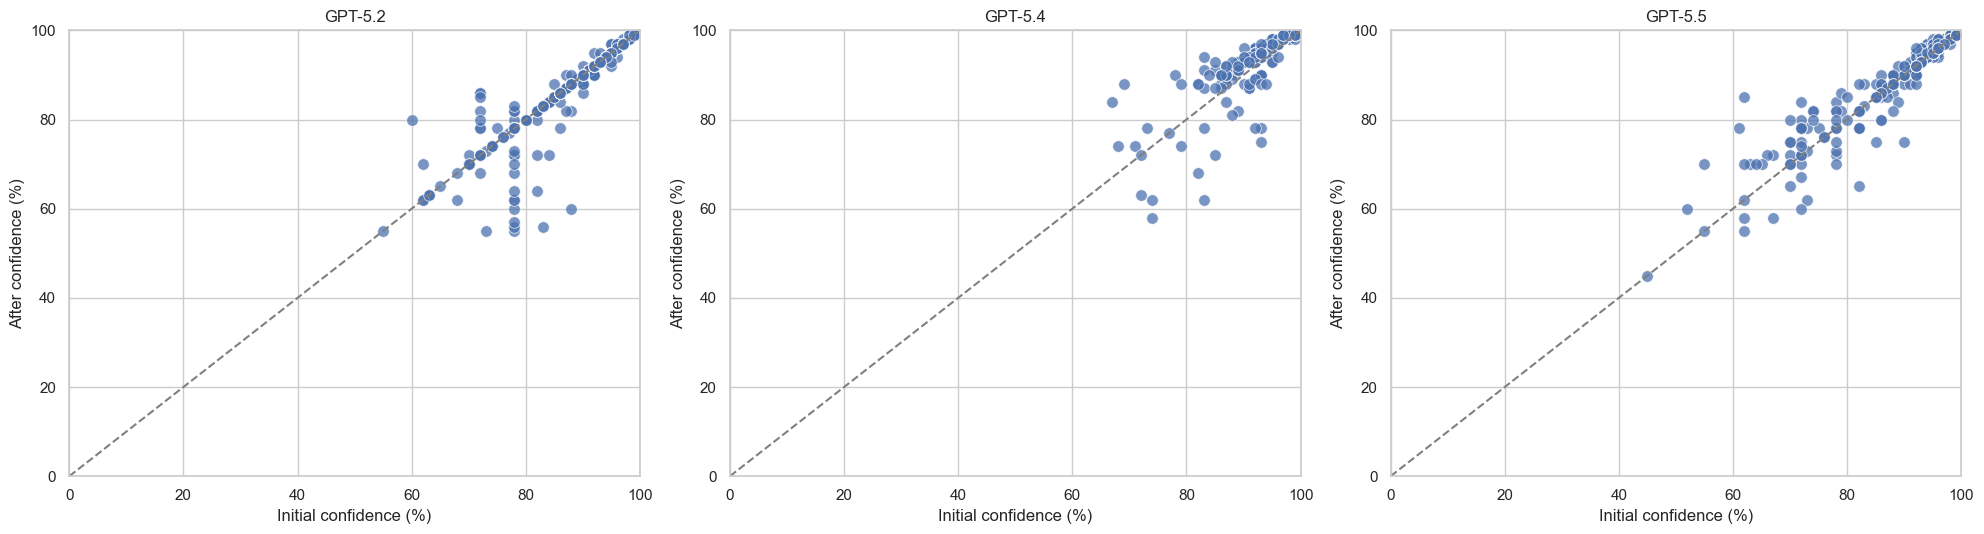

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
  "GPT-5.2": df_52,
  "GPT-5.4": df_54,
  "GPT-5.5": df_55
}

sns.set_theme(style="whitegrid")

plt.figure(figsize=(20, 5.5))

for i, (model_name, df_model) in enumerate(models.items(), 1):
  df = df_model.copy()

  df = df.dropna(
    subset=[
      "run2_initial_confidence",
      "run2_confidence",
      "run2_initial_answer",
      "answer_idx"
    ]
  ).copy()

  df["run2_initial_confidence"] = pd.to_numeric(df["run2_initial_confidence"], errors="coerce")
  df["run2_confidence"] = pd.to_numeric(df["run2_confidence"], errors="coerce")

  df = df.dropna(
    subset=[
      "run2_initial_confidence",
      "run2_confidence"
    ]
  ).copy()

  df["run2_initial_answer"] = df["run2_initial_answer"].astype(str).str.strip()
  df["answer_idx"] = df["answer_idx"].astype(str).str.strip()

  df["initial_correct"] = df["run2_initial_answer"] == df["answer_idx"]

  df_plot = df[df["initial_correct"] == True].copy()

  ax = plt.subplot(1, 3, i)

  sns.scatterplot(
    data=df_plot,
    x="run2_initial_confidence",
    y="run2_confidence",
    s=70,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    ax=ax
  )

  plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    color="gray",
    linewidth=1.5
  )

  plt.xlim(0, 100)
  plt.ylim(0, 100)

  plt.xlabel("Initial confidence (%)")
  plt.ylabel("After confidence (%)")
  plt.title(model_name)

plt.tight_layout()
plt.show()